# **Check Point 1 - Machine Learning Operations**
### Fondasi Sistem Prediksi *Risk Score* (Chicago Crimes -> Proxy Koordinat Jabodetabek)

# 0. Setup & Import Library

Stack standar data science: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`.
`scikit-learn` dipakai untuk `BallTree`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import BallTree

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
RNG = np.random.default_rng(42)
print("Setup selesai OK")


Setup selesai OK


# 1. Load Dataset — Chicago Crimes (2001–Present)

In [2]:
usecols = [
    "ID", "Date", "Primary Type", "Description",
    "Location Description", "Arrest",
    "Latitude", "Longitude", "Year"
]

dtypes = {
    "Primary Type": "category",
    "Description": "category",
    "Location Description": "category",
    "Arrest": "boolean",
    "Year": "Int16",
}

df = pd.read_csv(
    "../data/dataset/chicago_crimes.csv",
    usecols=usecols, dtype=dtypes
)

print("Shape mentah:", df.shape)
df.head()


Shape mentah: (8534663, 9)


,ID,Date,Primary Type,Description,Location Description,Arrest,Year,Latitude,Longitude
0,14165870,04/11/2026 12:00:00 AM,THEFT,$500 AND UNDER,STREET,False,2026,41.801025,-87.652621
1,14170655,04/11/2026 12:00:00 AM,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,RESIDENCE,False,2026,NaN,NaN
2,14164088,04/11/2026 12:00:00 AM,BATTERY,SIMPLE,STREET,False,2026,41.884097,-87.675228
3,14163678,04/11/2026 12:00:00 AM,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,APARTMENT,True,2026,41.977655,-87.697553
4,14164937,04/11/2026 12:00:00 AM,THEFT,THEFT FROM MOTOR VEHICLE,GAS STATION,False,2026,41.954538,-87.651148


**Subset yang diambil adalah 3 Tahun Terakhir**

In [3]:
# Strategi subset: WAKTU 3 

N_YEARS = 3   # -> justifikasi dijelaskan pada laporan
last_year = int(df["Year"].max())
df = df[df["Year"] >= last_year - (N_YEARS - 1)].copy()

print(f"Subset {last_year-(N_YEARS-1)}-{last_year}. Shape:", df.shape)

cat_cols = df.select_dtypes(include="category").columns
for c in cat_cols:
    df[c] = df[c].cat.remove_unused_categories()

Subset 2024-2026. Shape: (553919, 9)


# 2. Kualitas & Persiapan Data

- **Struktur & tipe data** — shape, dtype tiap kolom sudah benar?
- **Missing values** — proporsi null per kolom, acak atau sistematis?
- **Duplikat** — baris ganda penuh atau `ID` ganda?
- **Outlier & anomali** — koordinat di luar Chicago, `Year` tidak masuk akal, dll.
- **Rentang & validitas** — koordinat & timestamp dalam batas wajar?
- **Kardinalitas & konsistensi** — kategori `Primary Type`/`Description` seragam?

In [4]:
# Struktur & tipe data
print(df.shape)
print(df.dtypes)

(553919, 9)
ID                         int64
Date                         str
Primary Type            category
Description             category
Location Description    category
Arrest                   boolean
Year                       Int16
Latitude                 float64
Longitude                float64
dtype: object


Latitude                0.545748
Longitude               0.545748
Location Description    0.456926
ID                      0.000000
Date                    0.000000
Description             0.000000
Primary Type            0.000000
Year                    0.000000
Arrest                  0.000000
dtype: float64


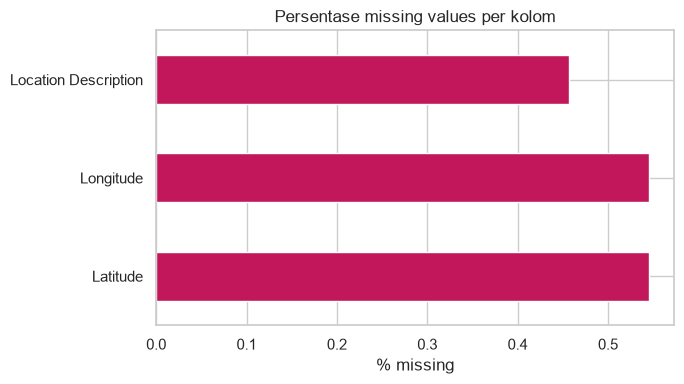

In [5]:
# Missing values per kolom (%)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct)

plt.figure(figsize=(7, 4))
missing_pct[missing_pct > 0].plot(kind="barh", color="#c2185b")
plt.title("Persentase missing values per kolom")
plt.xlabel("% missing")
plt.tight_layout(); plt.show()

In [6]:
# Duplikat
dup_full = df.duplicated().sum()
dup_id   = df.duplicated(subset=["ID"]).sum()
print(f"Baris duplikat penuh : {dup_full}")
print(f"ID duplikat          : {dup_id}")

df = df.drop_duplicates(subset=["ID"]).copy()

Baris duplikat penuh : 0
ID duplikat          : 0


In [7]:
# Parse tanggal & buang baris tanpa koordinat/tanggal valid
df["Datetime"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")

before = len(df)
df = df.dropna(subset=["Latitude", "Longitude", "Datetime"]).copy()

# Bounding box kasar Chicago -> menyingkirkan koordinat yang jelas keliru (mis. 0,0 atau typo)
CHI_LAT = (41.60, 42.05)
CHI_LON = (-87.95, -87.50)
df = df[df["Latitude"].between(*CHI_LAT) & df["Longitude"].between(*CHI_LON)].copy()

print(f"Baris sebelum cleaning: {before:,}")
print(f"Baris setelah cleaning: {len(df):,}  ({(len(df)/before*100):.1f}% tersisa)")


Baris sebelum cleaning: 553,919
Baris setelah cleaning: 550,896  (99.5% tersisa)


# 3. Transformasi Koordinat: Chicago → Jabodetabek (Proxy)

**Pendekatan:** normalisasi *min-max* linear per-axis, memetakan rentang `Latitude`/
`Longitude`

| Batas | Nilai | Keterangan |
|---|---|---|
| `lat_new_min` | -6.55 | batas selatan (mencakup Jakarta, Depok, sebagian Bogor) |
| `lat_new_max` | -6.10 | batas utara (pesisir Jakarta Utara) |
| `lon_new_min` | 106.55 | batas barat (sebagian besar wilayah Tangerang) |
| `lon_new_max` | 107.05 | batas timur (Kota Bekasi & sebagian Kab. Bekasi) |

Arah relatif dipertahankan: nilai `Latitude`/`Longitude` **minimum** di Chicago dipetakan
ke **minimum** di Jabodetabek, begitu pula maksimumnya — jadi titik paling utara di
Chicago tetap jadi titik paling utara pada peta baru, titik paling timur tetap paling
timur, dst. Pola spasial tetap konsisten posisi relatifnya, hanya "dipindah label" geografisnya ke
Jabodetabek.

In [8]:
# Simpan koordinat asli Chicago untuk ketertelusuran/audit
df["Latitude_Chicago_orig"] = df["Latitude"]
df["Longitude_Chicago_orig"] = df["Longitude"]

lat_old_min, lat_old_max = df["Latitude"].min(), df["Latitude"].max()
lon_old_min, lon_old_max = df["Longitude"].min(), df["Longitude"].max()

# Bounding box target: Jabodetabek
lat_new_min = -6.55   
lat_new_max = -6.10   
lon_new_min = 106.55  
lon_new_max = 107.05 

def minmax_scale(x, old_min, old_max, new_min, new_max):
    return new_min + (x - old_min) / (old_max - old_min) * (new_max - new_min)

df["Latitude"]  = minmax_scale(df["Latitude"],  lat_old_min, lat_old_max, lat_new_min, lat_new_max)
df["Longitude"] = minmax_scale(df["Longitude"], lon_old_min, lon_old_max, lon_new_min, lon_new_max)

print(f"Latitude  Chicago [{lat_old_min:.4f}, {lat_old_max:.4f}] -> Jabodetabek [{df['Latitude'].min():.4f}, {df['Latitude'].max():.4f}]")
print(f"Longitude Chicago [{lon_old_min:.4f}, {lon_old_max:.4f}] -> Jabodetabek [{df['Longitude'].min():.4f}, {df['Longitude'].max():.4f}]")
df[["Latitude_Chicago_orig", "Longitude_Chicago_orig", "Latitude", "Longitude"]].head()

Latitude  Chicago [41.6446, 42.0226] -> Jabodetabek [-6.5500, -6.1000]
Longitude Chicago [-87.9346, -87.5245] -> Jabodetabek [106.5500, 107.0500]


,Latitude_Chicago_orig,Longitude_Chicago_orig,Latitude,Longitude
0,41.801025,-87.652621,-6.363752,106.893805
2,41.884097,-87.675228,-6.264849,106.866238
3,41.977655,-87.697553,-6.153461,106.839015
4,41.954538,-87.651148,-6.180984,106.895601
5,41.951894,-87.747276,-6.184132,106.778383


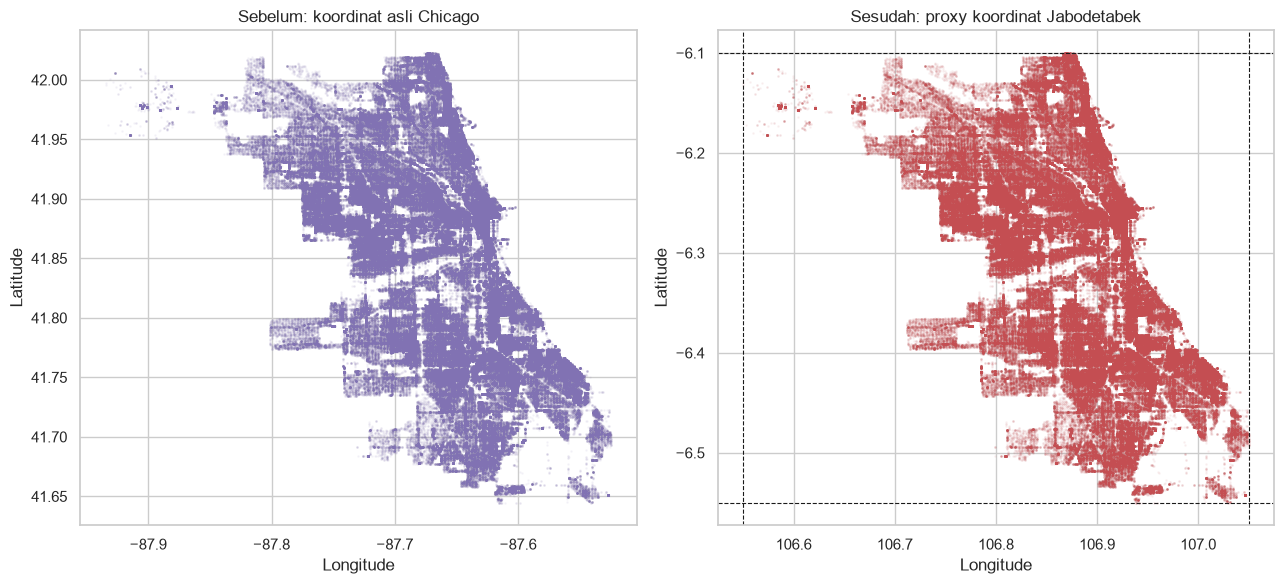

OK: seluruh titik berada dalam bounding box Jabodetabek.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].scatter(df["Longitude_Chicago_orig"], df["Latitude_Chicago_orig"], s=1, alpha=0.05, color="#8172B3")
axes[0].set_title("Sebelum: koordinat asli Chicago")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

axes[1].scatter(df["Longitude"], df["Latitude"], s=1, alpha=0.05, color="#C44E52")
axes[1].axvline(lon_new_min, color="k", ls="--", lw=0.8); axes[1].axvline(lon_new_max, color="k", ls="--", lw=0.8)
axes[1].axhline(lat_new_min, color="k", ls="--", lw=0.8); axes[1].axhline(lat_new_max, color="k", ls="--", lw=0.8)
axes[1].set_title("Sesudah: proxy koordinat Jabodetabek")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")

plt.tight_layout(); plt.show()

assert df["Latitude"].between(lat_new_min, lat_new_max).all()
assert df["Longitude"].between(lon_new_min, lon_new_max).all()
print("OK: seluruh titik berada dalam bounding box Jabodetabek.")

In [10]:
# Fitur waktu dasar (dipakai di EDA & feature engineering)
df["hour"]  = df["Datetime"].dt.hour
df["dow"]   = df["Datetime"].dt.dayofweek       # 0 = Senin
df["month"] = df["Datetime"].dt.month
df["is_weekend"] = df["dow"] >= 5

# Kardinalitas kategori penting -> ini akan jadi acuan menyusun severity table
print("Jumlah Primary Type unik :", df["Primary Type"].nunique())
print("Jumlah Description unik  :", df["Description"].nunique())
df[["Primary Type", "Description"]].value_counts().head(15)


Jumlah Primary Type unik : 31
Jumlah Description unik  : 331


Primary Type         Description                  
BATTERY              DOMESTIC BATTERY SIMPLE          43730
THEFT                $500 AND UNDER                   38068
                     OVER $500                        34828
BATTERY              SIMPLE                           34787
CRIMINAL DAMAGE      TO VEHICLE                       33067
ASSAULT              SIMPLE                           32926
MOTOR VEHICLE THEFT  AUTOMOBILE                       32841
THEFT                RETAIL THEFT                     30433
CRIMINAL DAMAGE      TO PROPERTY                      25341
THEFT                FROM BUILDING                    10546
WEAPONS VIOLATION    UNLAWFUL POSSESSION - HANDGUN     9822
THEFT                THEFT FROM MOTOR VEHICLE          9644
ASSAULT              AGGRAVATED - HANDGUN              9225
BURGLARY             FORCIBLE ENTRY                    8305
OTHER OFFENSE        TELEPHONE THREAT                  7363
Name: count, dtype: int64

# 4. Feature Engineering: Temporal & Spasial

- **Temporal (cyclical encoding)** — waktu bersifat siklikal, angka mentah menyesatkan model (jam 23 dan jam 0 sebenarnya berdekatan, tapi berjarak numerik 23).
- **Spasial (grid aggregation)** — koordinat kontinu diubah jadi sel grid diskrit agar bisa diagregasi & dibandingkan antar lokasi.

## 4.1 Fitur Temporal — Cyclical Encoding

$$x_{\sin} = \sin\!\left(\frac{2\pi \cdot v}{P}\right), \qquad
x_{\cos} = \cos\!\left(\frac{2\pi \cdot v}{P}\right)$$

dengan $P$ = panjang siklus (24 untuk jam, 7 untuk hari, 12 untuk bulan).

In [11]:
def cyclical_encode(values, period):
    radians = 2 * np.pi * np.asarray(values) / period
    return np.sin(radians), np.cos(radians)

df["hour_sin"],  df["hour_cos"]  = cyclical_encode(df["hour"], 24)
df["dow_sin"],   df["dow_cos"]   = cyclical_encode(df["dow"], 7)
df["month_sin"], df["month_cos"] = cyclical_encode(df["month"], 12)

df[["hour", "hour_sin", "hour_cos", "dow", "dow_sin", "dow_cos"]].head()


,hour,hour_sin,hour_cos,dow,dow_sin,dow_cos
0,0,0.0,1.0,5,-0.974928,-0.222521
2,0,0.0,1.0,5,-0.974928,-0.222521
3,0,0.0,1.0,5,-0.974928,-0.222521
4,0,0.0,1.0,5,-0.974928,-0.222521
5,0,0.0,1.0,5,-0.974928,-0.222521


In [12]:
# Pembuktian: jarak 23:00 -> 00:00 harus KECIL, jarak 00:00 -> 12:00 harus BESAR
def point(v, p):
    s, c = cyclical_encode(np.array([v]), p)
    return np.array([s[0], c[0]])

d_23_to_0 = np.linalg.norm(point(23, 24) - point(0, 24))
d_0_to_12 = np.linalg.norm(point(0, 24)  - point(12, 24))
print(f"Jarak 23:00 -> 00:00 = {d_23_to_0:.3f}  (harusnya KECIL)")
print(f"Jarak 00:00 -> 12:00 = {d_0_to_12:.3f}  (harusnya BESAR)")


Jarak 23:00 -> 00:00 = 0.261  (harusnya KECIL)
Jarak 00:00 -> 12:00 = 2.000  (harusnya BESAR)


Jarak 23→0 yang kecil dan jarak 0→12 yang besar di atas membuktikan encoding-nya bekerja seperti yang diharapkan, jam yang berdekatan secara kalender juga berdekatan secara angka.

## 4.2 Fitur Spasial — Grid Aggregation

Koordinat dibulatkan ke 2 desimal sehingga titik-titik berdekatan jatuh
ke sel yang sama.

In [13]:
ROUND_DECIMALS = 2   # -> justifikasi dijelaskan pada laporan

df["lat_r"] = df["Latitude"].round(ROUND_DECIMALS)
df["lon_r"] = df["Longitude"].round(ROUND_DECIMALS)
df["cell_id"] = df["lat_r"].astype(str) + "_" + df["lon_r"].astype(str)

print(f"Jumlah sel unik: {df['cell_id'].nunique():,}")
df[["Latitude", "Longitude", "lat_r", "lon_r", "cell_id"]].head()


Jumlah sel unik: 1,001


,Latitude,Longitude,lat_r,lon_r,cell_id
0,-6.363752,106.893805,-6.36,106.89,-6.36_106.89
2,-6.264849,106.866238,-6.26,106.87,-6.26_106.87
3,-6.153461,106.839015,-6.15,106.84,-6.15_106.84
4,-6.180984,106.895601,-6.18,106.90,-6.18_106.9
5,-6.184132,106.778383,-6.18,106.78,-6.18_106.78


# 5. Pseudo-Labeling → Membentuk Risk Score

**severity → temporal decay → spatial decay → agregasi per unit → normalisasi 0–100**

**Unit analisis** yang dipakai dalam notebook ini: **(sel grid × hari × jam)** — ini menjawab langsung definisi "risiko suatu lokasi pada waktu tertentu".

## 5.1 Severity Scoring — Metodologi Bertingkat (3-Tier)

**Solusi: fallback bertingkat (3-tier).**

| Tier | Kondisi | Sumber nilai |
|---|---|---|
| 1) Exact match | Kombinasi `(Primary Type, Description)` ada di tabel manual | Nilai spesifik yang di-assign manual |
| 2) Fallback per Primary Type | Kombinasi spesifik tidak ada, tapi `Primary Type`-nya dikenal | Nilai representatif untuk `Primary Type` itu |
| 3) Fallback global | `Primary Type`-nya sendiri benar-benar tidak dikenal/langka | Satu nilai default terakhir, seharusnya sangat jarang dipakai |

**Dasar penyusunan nilai :** urutan keparahan mengikuti *Hierarchy Rule* yang dipakai FBI UCR — daftar resmi mengurutkan kejahatan dari yang paling serius:
*murder → rape → robbery → aggravated assault → burglary → larceny-theft → motor vehicle theft* (arson dihitung terpisah). Urutan ini dipakai sebagai **kerangka ordinal** (kejahatan mana lebih berat dari mana), lalu diberi angka 0–100 dengan jarak antar-tingkat yang mencerminkan tingkat ancaman terhadap keselamatan (nyawa > kekerasan fisik > kerugian materi).

In [14]:
# TIER 1: tabel manual untuk kombinasi (Primary Type, Description) yang spesifik.

severity_table = {
    # ==========================================================
    # HOMICIDE
    # ==========================================================
    ("HOMICIDE", "FIRST DEGREE MURDER"): 100,

    # ==========================================================
    # CRIMINAL SEXUAL ASSAULT / SEX OFFENSE
    # ==========================================================
    ("CRIMINAL SEXUAL ASSAULT", "AGGRAVATED"): 95,
    ("CRIMINAL SEXUAL ASSAULT", "NON-AGGRAVATED"): 85,

    ("SEX OFFENSE", "CRIMINAL SEXUAL ABUSE"): 75,
    ("SEX OFFENSE", "PUBLIC INDECENCY"): 20,

    # ==========================================================
    # ROBBERY
    # ==========================================================
    ("ROBBERY", "AGGRAVATED"): 75,
    ("ROBBERY", "ARMED - HANDGUN"): 82,
    ("ROBBERY", "STRONG ARM - NO WEAPON"): 60,
    ("ROBBERY", "AGGRAVATED VEHICULAR HIJACKING"): 90,

    # ==========================================================
    # ASSAULT
    # ==========================================================
    ("ASSAULT", "SIMPLE"): 45,
    ("ASSAULT", "AGGRAVATED - HANDGUN"): 78,
    ("ASSAULT", "AGGRAVATED - OTHER DANGEROUS WEAPON"): 70,
    ("ASSAULT", "AGGRAVATED - KNIFE / CUTTING INSTRUMENT"): 72,

    # ==========================================================
    # BATTERY
    # ==========================================================
    ("BATTERY", "SIMPLE"): 50,
    ("BATTERY", "DOMESTIC BATTERY SIMPLE"): 52,
    ("BATTERY", "AGGRAVATED - HANDGUN"): 78,
    ("BATTERY", "AGGRAVATED - OTHER DANGEROUS WEAPON"): 70,

    # ==========================================================
    # WEAPONS VIOLATION
    # ==========================================================
    ("WEAPONS VIOLATION", "UNLAWFUL POSSESSION - HANDGUN"): 58,
    ("WEAPONS VIOLATION", "RECKLESS FIREARM DISCHARGE"): 65,

    # ==========================================================
    # BURGLARY
    # ==========================================================
    ("BURGLARY", "FORCIBLE ENTRY"): 48,
    ("BURGLARY", "UNLAWFUL ENTRY"): 42,
    ("BURGLARY", "ATTEMPT FORCIBLE ENTRY"): 40,
    ("BURGLARY", "BURGLARY FROM MOTOR VEHICLE"): 35,

    # ==========================================================
    # MOTOR VEHICLE THEFT
    # ==========================================================
    ("MOTOR VEHICLE THEFT", "AUTOMOBILE"): 40,
    ("MOTOR VEHICLE THEFT", "ATTEMPT - AUTOMOBILE"): 30,
    ("MOTOR VEHICLE THEFT", "THEFT / RECOVERY - AUTOMOBILE"): 35,
    ("MOTOR VEHICLE THEFT", "TRUCK, BUS, MOTOR HOME"): 35,

    # ==========================================================
    # THEFT
    # ==========================================================
    ("THEFT", "POCKET-PICKING"): 32,
    ("THEFT", "OVER $500"): 28,
    ("THEFT", "$500 AND UNDER"): 20,
    ("THEFT", "RETAIL THEFT"): 18,
    ("THEFT", "FROM BUILDING"): 22,
    ("THEFT", "THEFT FROM MOTOR VEHICLE"): 22,
    ("THEFT", "PURSE-SNATCHING"): 35,
    ("THEFT", "ATTEMPT THEFT"): 15,

    # ==========================================================
    # NARCOTICS
    # ==========================================================
    ("NARCOTICS", "POSSESS - CANNABIS 30 GRAMS OR LESS"): 22,
    ("NARCOTICS", "POSSESS - HEROIN (WHITE)"): 30,
    ("NARCOTICS", "POSSESS - CRACK"): 28,
    ("NARCOTICS", "POSSESSION OF DRUG EQUIPMENT"): 18,
    ("NARCOTICS", "ATTEMPT POSSESSION NARCOTICS"): 20,
    ("NARCOTICS", "FOUND SUSPECT NARCOTICS"): 15,

    # ==========================================================
    # CRIMINAL DAMAGE
    # ==========================================================
    ("CRIMINAL DAMAGE", "TO VEHICLE"): 12,
    ("CRIMINAL DAMAGE", "TO PROPERTY"): 12,
    ("CRIMINAL DAMAGE", "CRIMINAL DEFACEMENT"): 12,
    ("CRIMINAL DAMAGE", "TO CITY OF CHICAGO PROPERTY"): 12,

    # ==========================================================
    # CRIMINAL TRESPASS
    # ==========================================================
    ("CRIMINAL TRESPASS", "TO LAND"): 10,
    ("CRIMINAL TRESPASS", "TO RESIDENCE"): 18,
    ("CRIMINAL TRESPASS", "TO STATE SUP LAND"): 10,
    ("CRIMINAL TRESPASS", "TO VEHICLE"): 12,

    # ==========================================================
    # DECEPTIVE PRACTICE
    # ==========================================================
    ("DECEPTIVE PRACTICE", "FINANCIAL IDENTITY THEFT OVER $ 300"): 25,
    ("DECEPTIVE PRACTICE", "FINANCIAL IDENTITY THEFT $300 AND UNDER"): 20,
    ("DECEPTIVE PRACTICE", "FRAUD OR CONFIDENCE GAME"): 20,
    ("DECEPTIVE PRACTICE", "FORGERY"): 20,
    ("DECEPTIVE PRACTICE", "BOGUS CHECK"): 18,
    ("DECEPTIVE PRACTICE", "COUNTERFEITING DOCUMENT"): 20,
    ("DECEPTIVE PRACTICE", "CREDIT CARD FRAUD"): 15,
    ("DECEPTIVE PRACTICE", "ILLEGAL USE CASH CARD"): 15,

    # ==========================================================
    # OTHER OFFENSE
    # ==========================================================
    ("OTHER OFFENSE", "VIOLATE ORDER OF PROTECTION"): 30,
    ("OTHER OFFENSE", "TELEPHONE THREAT"): 20,
    ("OTHER OFFENSE", "HARASSMENT BY TELEPHONE"): 15,
    ("OTHER OFFENSE", "HARASSMENT BY ELECTRONIC MEANS"): 15,
    ("OTHER OFFENSE", "FALSE / STOLEN / ALTERED TRP"): 10,
    ("OTHER OFFENSE", "OTHER VEHICLE OFFENSE"): 12,
    ("OTHER OFFENSE", "OTHER CRIME INVOLVING PROPERTY"): 12,

    # ==========================================================
    # PROSTITUTION
    # ==========================================================
    ("PROSTITUTION", "SOLICIT ON PUBLIC WAY"): 18,

    # ==========================================================
    # PUBLIC PEACE VIOLATION
    # ==========================================================
    ("PUBLIC PEACE VIOLATION", "RECKLESS CONDUCT"): 18,

    # ==========================================================
    # OFFENSE INVOLVING CHILDREN
    # ==========================================================
    ("OFFENSE INVOLVING CHILDREN", "CHILD ABUSE"): 85,

    # ==========================================================
    # ARSON
    # ==========================================================
    ("ARSON", "BY FIRE"): 60,
}

# TIER 2: kalau kombinasi spesifiknya nggak ketemu, fallback ke rata-rata per Primary Type.
# Angkanya disusun berdasar urutan keparahan ala UCR + logika ancaman ke keselamatan publik.

primary_type_default = {
    "HOMICIDE":                98,
    "CRIMINAL SEXUAL ASSAULT": 90,   
    "KIDNAPPING":              88,
    "ROBBERY":                 72,
    "WEAPONS VIOLATION":       60,
    "ASSAULT":                 52,
    "BATTERY":                 50,
    "ARSON":                   55,
    "BURGLARY":                45,
    "MOTOR VEHICLE THEFT":     38,
    "NARCOTICS":               28,
    "THEFT":                   25,
    "DECEPTIVE PRACTICE":      20,
    "CRIMINAL DAMAGE":         15,
    "CRIMINAL TRESPASS":       15,
    "PUBLIC PEACE VIOLATION":  15,
    "OTHER OFFENSE":           18,
    "LIQUOR LAW VIOLATION":    10,
    "GAMBLING":                10,
    "INTIMIDATION":            35,
    "STALKING":                45,
    "OFFENSE INVOLVING CHILDREN": 80,
    "HUMAN TRAFFICKING":       92,
    "CONCEALED CARRY LICENSE VIOLATION": 25,
    "PROSTITUTION": 18,
    "SEX OFFENSE": 60,
}

# TIER 3: fallback terakhir kalau Primary Type-nya sendiri nggak dikenali
GLOBAL_DEFAULT_SEVERITY = 20

In [15]:
exact_key = list(zip(df["Primary Type"], df["Description"]))
exact_severity = pd.Series(exact_key, index=df.index).map(severity_table)

type_fallback_severity = df["Primary Type"].map(primary_type_default)

df["severity"] = exact_severity.fillna(type_fallback_severity).fillna(GLOBAL_DEFAULT_SEVERITY)

df["severity_tier"] = np.select(
    [exact_severity.notna(), type_fallback_severity.notna()],
    ["1_exact_match", "2_type_fallback"],
    default="3_global_default",
)

tier_pct = df["severity_tier"].value_counts(normalize=True).mul(100).round(1)
print("Distribusi tier severity (%):")
print(tier_pct)
print()
print("Kalau tier 3 (global default) masih besar persentasenya, tabel di atas PERLU DIPERLUAS.")


Distribusi tier severity (%):
severity_tier
1_exact_match       89.9
2_type_fallback      9.7
3_global_default     0.4
Name: proportion, dtype: float64

Kalau tier 3 (global default) masih besar persentasenya, tabel di atas PERLU DIPERLUAS.


## 5.2 Temporal Decay — Recency

`w_time = exp(-λ · Δt)` : kejadian lebih baru menimbang lebih besar.
Menggunakan **exponential decay dengan half-life-days 180**.

In [16]:
REFERENCE_DATE = df["Datetime"].max()  
df["age_days"] = (REFERENCE_DATE - df["Datetime"]).dt.total_seconds() / 86400

# Half-life 6 bulan berarti kejadian setahun lalu masih menyumbang ~25% bobot
# penuhnya -- cukup untuk menangkap pola musiman tahunan (mis. kenaikan kejahatan musim panas),
# tapi kejadian 2-3 tahun lalu sudah meluruh jauh (<10%).

HALF_LIFE_DAYS = 180 
LAMBDA = np.log(2) / HALF_LIFE_DAYS

df["w_time"] = np.exp(-LAMBDA * df["age_days"])
df["event_value"] = df["severity"] * df["w_time"]

print(f"Reference date : {REFERENCE_DATE}")
print(f"Half-life      : {HALF_LIFE_DAYS} hari  (lambda = {LAMBDA:.5f})")
print(df[["age_days", "w_time"]].describe().round(3))


Reference date : 2026-04-11 00:00:00
Half-life      : 180 hari  (lambda = 0.00385)
         age_days      w_time
count  550896.000  550896.000
mean      427.927       0.285
std       236.914       0.249
min         0.000       0.041
25%       226.375       0.087
50%       434.795       0.187
75%       633.750       0.418
max       831.000       1.000


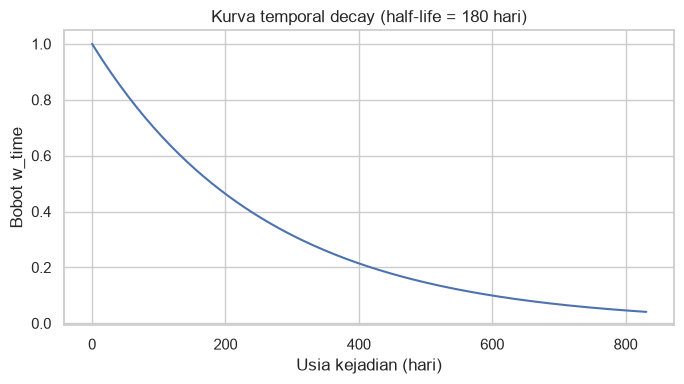

In [17]:
# Visual cek decay curve
ages = np.linspace(0, df["age_days"].max(), 200)
weights = np.exp(-LAMBDA * ages)

plt.figure(figsize=(7, 4))
plt.plot(ages, weights)
plt.title(f"Kurva temporal decay (half-life = {HALF_LIFE_DAYS} hari)")
plt.xlabel("Usia kejadian (hari)"); plt.ylabel("Bobot w_time")
plt.tight_layout(); plt.show()


### Membentuk tabel unit analisis (sel × hari × jam)

Jumlahkan `event_value` (severity × recency) ke tiap unit analisis, jadi `base_value`. Sekaligus bawa `crime_count` (frekuensi kejadian) sebagai fitur agregat tambahan, berbeda sifatnya dari `base_value` (yang menimbang keparahan × kebaruan).

In [18]:
unit = (df.groupby(["cell_id", "lat_r", "lon_r", "dow", "hour"], as_index=False)
          .agg(base_value  = ("event_value", "sum"),
               crime_count = ("ID", "size"),
               arrest_rate = ("Arrest", "mean")))
print("Jumlah baris unit (sel x hari x jam):", f"{len(unit):,}")
unit.head()


Jumlah baris unit (sel x hari x jam): 119,454


,cell_id,lat_r,lon_r,dow,hour,base_value,crime_count,arrest_rate
0,-6.11_106.69,-6.11,106.69,0,0,1.830107,1,0.0
1,-6.11_106.69,-6.11,106.69,0,3,8.456103,1,0.0
2,-6.11_106.69,-6.11,106.69,0,12,6.154066,3,0.0
3,-6.11_106.69,-6.11,106.69,0,15,1.560722,1,0.0
4,-6.11_106.69,-6.11,106.69,1,9,7.144097,1,0.0


## 5.3 Spatial Decay — Proximity

`w_dist = exp(-d² / 2σ²)` : sinyal dari sel dekat lebih relevan.
Menggunakan `BallTree` (scikit-learn) dengan metrik `haversine` untuk menghitung **jarak sesungguhnya antar-koordinat** (dalam meter), lalu bobot Gaussian berdasarkan jaraknya

In [19]:
EARTH_RADIUS_M = 6_371_000

SIGMA_METERS = 1500 

cells = unit[["cell_id", "lat_r", "lon_r"]].drop_duplicates().reset_index(drop=True)
coords_rad = np.radians(cells[["lat_r", "lon_r"]].values)

tree = BallTree(coords_rad, metric="haversine")

# Cari semua tetangga dalam radius 3*sigma (cukup untuk menangkap >99% bobot Gaussian)
radius_rad = (3 * SIGMA_METERS) / EARTH_RADIUS_M
neighbor_idx, neighbor_dist = tree.query_radius(coords_rad, r=radius_rad,
                                                 return_distance=True)

print(f"Rata-rata jumlah tetangga per sel (radius {3*SIGMA_METERS} m): "
      f"{np.mean([len(n) for n in neighbor_idx]):.1f}")


Rata-rata jumlah tetangga per sel (radius 4500 m): 40.4


In [20]:
# Bangun lookup base_value per (cell_id, dow, hour) untuk agregasi tetangga
base_lookup = unit.set_index(["cell_id", "dow", "hour"])["base_value"].to_dict()
cell_id_arr = cells["cell_id"].values

def spatial_smooth(row):
    center_pos = cells.index[cells["cell_id"] == row["cell_id"]][0]
    idxs  = neighbor_idx[center_pos]
    dists = neighbor_dist[center_pos] * EARTH_RADIUS_M   # radian -> meter
    weights = np.exp(-(dists ** 2) / (2 * SIGMA_METERS ** 2))

    values = np.array([
        base_lookup.get((cell_id_arr[i], row["dow"], row["hour"]), 0.0)
        for i in idxs
    ])
    if weights.sum() == 0:
        return row["base_value"]
    return float(np.average(values, weights=weights))

unit["risk_raw"] = unit.apply(spatial_smooth, axis=1)
unit[["cell_id", "dow", "hour", "base_value", "risk_raw"]].head()

,cell_id,dow,hour,base_value,risk_raw
0,-6.11_106.69,0,0,1.830107,7.074982
1,-6.11_106.69,0,3,8.456103,4.624464
2,-6.11_106.69,0,12,6.154066,3.237054
3,-6.11_106.69,0,15,1.560722,1.052707
4,-6.11_106.69,1,9,7.144097,8.117792


## 5.4 Normalisasi → Risk Score 0–100

`risk_raw` biasanya sangat *skewed*. Baseline di bawah pakai **`log1p` + min–max**
(lebih tahan outlier dibanding min–max langsung).

count    119454.00
mean         60.08
std          13.40
min           0.00
25%          52.09
50%          61.84
75%          69.98
max         100.00
Name: risk_score, dtype: float64


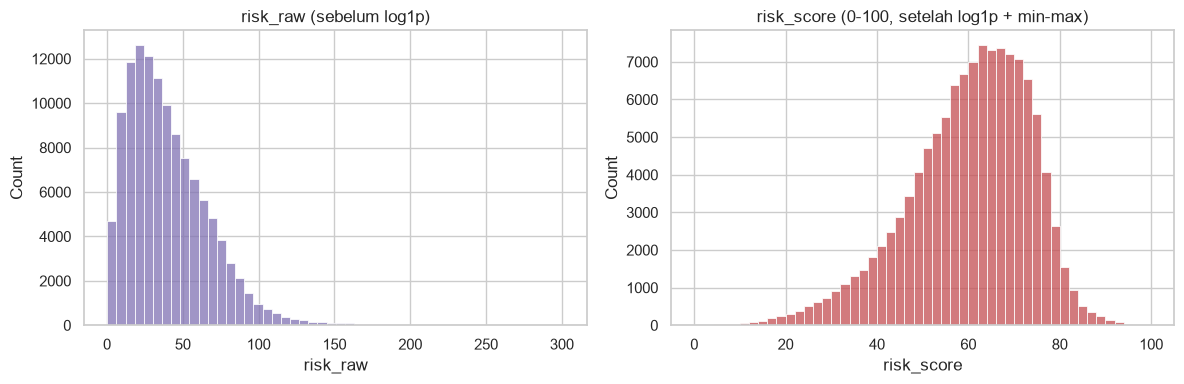

In [21]:
rr_log = np.log1p(unit["risk_raw"])
unit["risk_score"] = 100 * (rr_log - rr_log.min()) / (rr_log.max() - rr_log.min())

print(unit["risk_score"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(unit["risk_raw"], bins=50, ax=axes[0], color="#8172B3")
axes[0].set_title("risk_raw (sebelum log1p)")
sns.histplot(unit["risk_score"], bins=50, ax=axes[1], color="#C44E52")
axes[1].set_title("risk_score (0-100, setelah log1p + min-max)")
plt.tight_layout(); plt.show()


`risk_raw` di kiri jelas condong ke kanan, kebanyakan sel bernilai rendah dan beberapa sel jauh lebih tinggi, ini gambaran hotspot secara numerik. Setelah `log1p` + min-max, sebarannya lebih merata sehingga skala 0-100 bisa dibaca dan dibandingkan antar sel secara wajar.

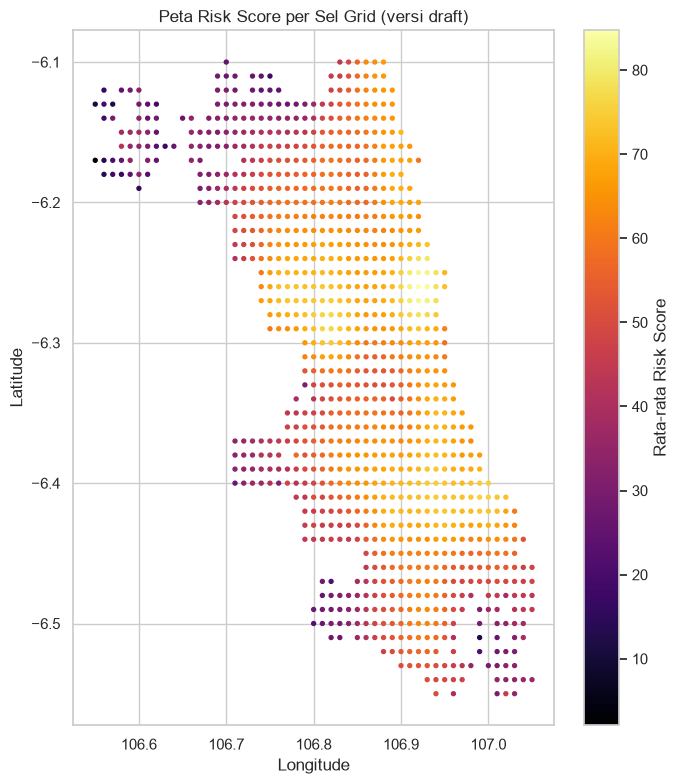

In [22]:
# Peta Risk Score per sel
cell_risk = unit.groupby(["lat_r", "lon_r"], as_index=False)["risk_score"].mean()

plt.figure(figsize=(7, 8))
sc = plt.scatter(cell_risk["lon_r"], cell_risk["lat_r"], c=cell_risk["risk_score"],
                 cmap="inferno", s=8)
plt.colorbar(sc, label="Rata-rata Risk Score")
plt.title("Peta Risk Score per Sel Grid (versi draft)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()


# 6. Menyusun & Menyimpan Dataset Akhir

In [23]:
unit["hour_sin"], unit["hour_cos"] = cyclical_encode(unit["hour"], 24)
unit["dow_sin"],  unit["dow_cos"]  = cyclical_encode(unit["dow"], 7)

final = unit[[
    # identitas / lokasi
    "cell_id", "lat_r", "lon_r",
    # waktu (raw + cyclical)
    "dow", "hour", "dow_sin", "dow_cos", "hour_sin", "hour_cos",
    # fitur agregat
    "crime_count", "arrest_rate",
    # label
    "risk_score",
]].copy()

print("Shape dataset akhir:", final.shape)
print("Kolom:", list(final.columns))
final.head()


Shape dataset akhir: (119454, 12)
Kolom: ['cell_id', 'lat_r', 'lon_r', 'dow', 'hour', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos', 'crime_count', 'arrest_rate', 'risk_score']


,cell_id,lat_r,lon_r,dow,hour,dow_sin,dow_cos,hour_sin,hour_cos,crime_count,arrest_rate,risk_score
0,-6.11_106.69,-6.11,106.69,0,0,0.000000,1.00000,0.000000e+00,1.000000,1,0.0,34.989507
1,-6.11_106.69,-6.11,106.69,0,3,0.000000,1.00000,7.071068e-01,0.707107,1,0.0,28.500710
2,-6.11_106.69,-6.11,106.69,0,12,0.000000,1.00000,1.224647e-16,-1.000000,3,0.0,23.418378
3,-6.11_106.69,-6.11,106.69,0,15,0.000000,1.00000,-7.071068e-01,-0.707107,1,0.0,10.415326
4,-6.11_106.69,-6.11,106.69,1,9,0.781831,0.62349,7.071068e-01,-0.707107,1,0.0,37.168742


In [25]:
import pyarrow
print(pyarrow.__version__)

final.to_csv("../data/dataset/features_labels.csv", index=False)
print("Tersimpan: data/dataset/features_labels.csv ✅")

try:
    final.to_parquet("../data/dataset/features_labels.parquet", index=False)
    print("Tersimpan: data/dataset/features_labels.parquet ✅")
except Exception as e:
    print("Parquet dilewati (engine belum terpasang) — CSV sudah cukup untuk HO2.")

25.0.0
Tersimpan: data/dataset/features_labels.csv ✅
Tersimpan: data/dataset/features_labels.parquet ✅
